In [74]:
from pathlib import Path
import pandas as pd
from IPython.display import display

FILE = Path("MI_Technovation_Raw.xlsx")

if not FILE.exists():
    raise FileNotFoundError(
        "MI_Technovation_Raw.xlsx was not found. "
        "Place it in the same folder as the notebook."
    )

raw = pd.read_excel(
    FILE,
    sheet_name="Sheet 1",
    header=27
)

print("Raw LSEG Excel file loaded successfully.")

Raw LSEG Excel file loaded successfully.


In [75]:
# Stage 2: Price-data cleaning

price = raw[["Local Time", "Close", "Volume"]].copy()
price.columns = ["Timestamp", "Close", "Volume"]

price["Timestamp"] = pd.to_datetime(
    price["Timestamp"],
    errors="coerce"
)

price["Close"] = pd.to_numeric(
    price["Close"],
    errors="coerce"
)

price["Volume"] = pd.to_numeric(
    price["Volume"],
    errors="coerce"
)

# Retain the exact assignment period
start = pd.Timestamp("2026-04-13 09:00:00")
end = pd.Timestamp("2026-07-08 17:00:00")

price = price[
    price["Timestamp"].between(start, end)
].copy()

rows_before = len(price)
empty_close = price["Close"].isna().sum()

# Remove only observations with an empty closing price
clean = (
    price.dropna(subset=["Close"])
         .sort_values("Timestamp")
         .copy()
)

duplicate_count = clean["Timestamp"].duplicated().sum()

cleaning_summary = pd.DataFrame({
    "Cleaning Check": [
        "Rows before cleaning",
        "Empty Close rows removed",
        "Valid rows retained",
        "Duplicate timestamps"
    ],
    "Result": [
        rows_before,
        empty_close,
        len(clean),
        duplicate_count
    ]
})

display(cleaning_summary)

# Export the cleaned dataset using the column names required by FINBERT

clean_for_finbert = clean[
    ["Timestamp", "Close", "Volume"]
].copy()

clean_for_finbert.rename(
    columns={"Timestamp": "Exchange Time"},
    inplace=True
)

FINBERT_FILE = Path("MI_Technovation_Cleaned.xlsx")
clean_for_finbert.to_excel(
    FINBERT_FILE,
    index=False
)

print("Exported columns:")
print(clean_for_finbert.columns.tolist())   

,Cleaning Check,Result
0,Rows before cleaning,19928
1,Empty Close rows removed,5338
2,Valid rows retained,14590
3,Duplicate timestamps,0


Exported columns:
['Exchange Time', 'Close', 'Volume']


In [76]:
# Stage 3: Positive average daily return verification

clean["Date"] = clean["Timestamp"].dt.date

daily = (
    clean.groupby("Date", as_index=False)
         .agg(Close=("Close", "last"))
)

daily["Daily Return (%)"] = (
    daily["Close"].pct_change() * 100
)

mean_daily_return = daily["Daily Return (%)"].mean()
return_observations = daily["Daily Return (%)"].notna().sum()

return_summary = pd.DataFrame({
    "Verification Measure": [
        "Trading days",
        "Daily return observations",
        "Average daily return",
        "Required condition",
        "Outcome"
    ],
    "Result": [
        len(daily),
        return_observations,
        f"{mean_daily_return:.4f}%",
        "Greater than 0%",
        "Satisfied" if mean_daily_return > 0 else "Not satisfied"
    ]
})

display(return_summary)

,Verification Measure,Result
0,Trading days,58
1,Daily return observations,57
2,Average daily return,0.8849%
3,Required condition,Greater than 0%
4,Outcome,Satisfied


In [77]:
# Stage 4: Descriptive statistics

# Continue using the cleaned data already held in memory
minute = clean[
    ["Timestamp", "Close", "Volume"]
].copy()

# Extract the trading date from each one-minute timestamp
minute["Date"] = minute["Timestamp"].dt.normalize()

# Select the last valid closing price and calculate volume for each trading day
daily_analysis = (
    minute.groupby("Date", as_index=False)
    .agg(
        Daily_Close=("Close", "last"),
        Daily_Volume=(
            "Volume",
            lambda x: x.sum(min_count=1)
        ),
        Valid_Bars=("Close", "size")
    )
)

# Place the daily closing prices into a DataFrame
df = (
    daily_analysis
    .set_index("Date")[["Daily_Close"]]
    .rename(
        columns={
            "Daily_Close": "MI Technovation"
        }
    )
)

# Compute daily percentage returns
returns = df.pct_change(fill_method=None) * 100             # Calculate percentage returns for MI Technovation

# Store the daily returns in the daily analysis table
daily_analysis["Daily Return (%)"] = (
    returns["MI Technovation"].to_numpy()
)

# Drop the first row since it contains NaN (no previous closing price for the first trading day)
returns.dropna(inplace=True)

# Select the MI Technovation daily-return series
return_series = returns["MI Technovation"]

# Calculate the descriptive statistics of daily returns
mean_return = return_series.mean()                            # Average daily return
median_return = return_series.median()                        # Median daily return
minimum_return = return_series.min()                          # Lowest daily return
maximum_return = return_series.max()                          # Highest daily return
standard_deviation = return_series.std()                      # Standard deviation (volatility)
skewness = return_series.skew()                               # Skewness (asymmetry)
pearson_kurtosis = return_series.kurtosis() + 3               # Pearson kurtosis (fat tails or peakedness)

# Calculate the additional price statistics required by the assignment
minimum_price = minute["Close"].min()                         # Lowest one-minute closing price
maximum_price = minute["Close"].max()                         # Highest one-minute closing price
price_range = maximum_price - minimum_price                   # Difference between maximum and minimum price
trading_days = len(daily_analysis)                            # Number of trading days
return_observations = len(return_series)                      # Number of calculated daily returns

# Combine all descriptive statistics into one table
descriptive_table = pd.DataFrame({
    "Statistic": [
        "Mean daily return",
        "Median daily return",
        "Minimum daily return",
        "Maximum daily return",
        "Daily-return standard deviation",
        "Daily-return skewness",
        "Daily-return kurtosis (Pearson)",
        "Minimum one-minute closing price",
        "Maximum one-minute closing price",
        "One-minute closing-price range",
        "Number of trading days",
        "Daily-return observations"
    ],
    "Result": [
        f"{mean_return:.4f}%",
        f"{median_return:.4f}%",
        f"{minimum_return:.4f}%",
        f"{maximum_return:.4f}%",
        f"{standard_deviation:.4f}%",
        f"{skewness:.4f}",
        f"{pearson_kurtosis:.4f}",
        f"RM{minimum_price:.2f}",
        f"RM{maximum_price:.2f}",
        f"RM{price_range:.2f}",
        trading_days,
        return_observations
    ]
})

# Display all descriptive statistics in one table
display(descriptive_table)

,Statistic,Result
0,Mean daily return,0.8849%
1,Median daily return,0.6452%
2,Minimum daily return,-6.2241%
3,Maximum daily return,9.9476%
4,Daily-return standard deviation,3.1641%
5,Daily-return skewness,0.2946
6,Daily-return kurtosis (Pearson),3.4146
7,Minimum one-minute closing price,RM2.86
8,Maximum one-minute closing price,RM5.06
9,One-minute closing-price range,RM2.20


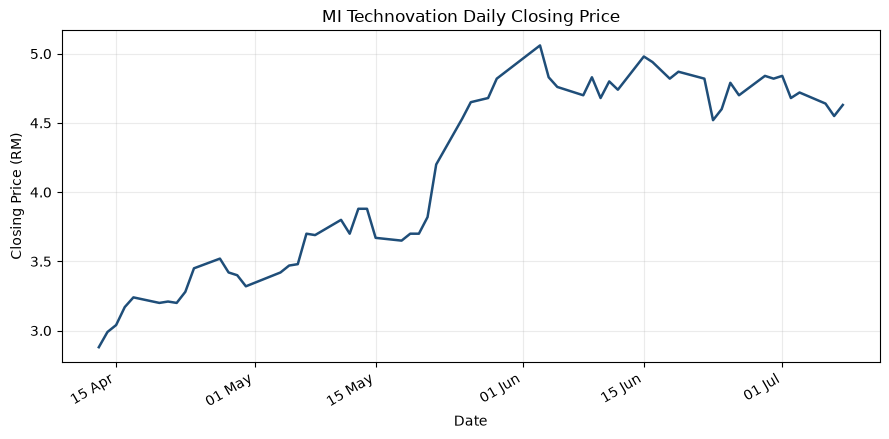

Chart created: MI_Technovation_Daily_Closing_Price.png


In [78]:
# Stage 5: Daily closing-price chart

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the daily closing-price chart
fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

ax.plot(
    daily_analysis["Date"],
    daily_analysis["Daily_Close"],
    color="#1F4E79",
    linewidth=1.8
)

# Add the chart title and axis labels
ax.set_title(
    "MI Technovation Daily Closing Price"
)

ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (RM)")

# Add light gridlines for readability
ax.grid(alpha=0.25)

# Format the date labels
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

fig.autofmt_xdate()
fig.tight_layout()

# Save the chart as a high-resolution PNG file
CHART_FILE = "MI_Technovation_Daily_Closing_Price.png"

fig.savefig(
    CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

print(f"Chart created: {CHART_FILE}")

In [79]:
# Stage 6: Missing observations and liquidity analysis

# Retrieve the cleaning results calculated in Stage 2
cleaning_values = cleaning_summary.set_index(
    "Cleaning Check"
)["Result"]

raw_rows = int(
    cleaning_values.loc["Rows before cleaning"]
)                                                               # Total observations before cleaning

missing_close = int(
    cleaning_values.loc["Empty Close rows removed"]
)                                                               # Empty closing-price observations removed

valid_rows = int(
    cleaning_values.loc["Valid rows retained"]
)                                                               # Valid observations retained

# Check that the cleaning summary matches the cleaned dataset
if valid_rows != len(minute):
    raise ValueError(
        "The valid-row count does not match the cleaned dataset."
    )

# Calculate missing observations and valid-price coverage
missing_percentage = (
    missing_close / raw_rows
) * 100                                                         # Percentage of empty closing prices

valid_coverage = (
    valid_rows / raw_rows
) * 100                                                         # Percentage of valid closing prices


# Identify the Bursa Malaysia morning and afternoon sessions
clock_minute = (
    minute["Timestamp"].dt.hour * 60
    + minute["Timestamp"].dt.minute
)

minute["Session"] = pd.NA

minute.loc[
    clock_minute.between(540, 750),
    "Session"
] = "Morning"                                                   # Morning session: 09:00–12:30

minute.loc[
    clock_minute.between(870, 1020),
    "Session"
] = "Afternoon"                                                 # Afternoon session: 14:30–17:00

# Retain observations within the two trading sessions
within_session = minute.dropna(
    subset=["Session"]
).copy()


# Obtain the previous valid price within the same date and session
within_session["Previous_Close"] = (
    within_session.groupby(
        ["Date", "Session"]
    )["Close"].shift()
)

# Exclude the first observation of each trading session
comparable_prices = (
    within_session["Previous_Close"].notna()
)

# Calculate the percentage of consecutive prices that remained unchanged
unchanged_percentage = (
    within_session.loc[
        comparable_prices,
        "Close"
    ]
    .eq(
        within_session.loc[
            comparable_prices,
            "Previous_Close"
        ]
    )
    .mean() * 100
)


# Calculate the interval between consecutive valid observations
within_session["Interval_Minutes"] = (
    within_session.groupby(
        ["Date", "Session"]
    )["Timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

# Identify the largest interval within a trading session
maximum_interval = (
    within_session["Interval_Minutes"].max()
)

largest_interval_row = within_session.loc[
    within_session["Interval_Minutes"].idxmax()
]

interval_end = largest_interval_row["Timestamp"]

interval_start = (
    interval_end
    - pd.Timedelta(minutes=maximum_interval)
)


# Calculate the required liquidity measures
total_volume = minute["Volume"].sum()                           # Total trading volume
average_daily_volume = daily_analysis["Daily_Volume"].mean()   # Average daily trading volume
median_daily_volume = daily_analysis["Daily_Volume"].median()  # Median daily trading volume
average_valid_bars = daily_analysis["Valid_Bars"].mean()       # Average valid one-minute bars per day
missing_volume = minute["Volume"].isna().sum()                  # Missing volume fields after cleaning


# Create a summary table for missing observations and liquidity
liquidity_table = pd.DataFrame({
    "Liquidity Measure": [
        "Raw timestamped observations",
        "Empty closing-price observations",
        "Empty closing-price rate",
        "Valid closing-price coverage",
        "Valid one-minute observations",
        "Average valid bars per trading day",
        "Total trading volume",
        "Average daily volume",
        "Median daily volume",
        "Unchanged consecutive valid prices",
        "Largest within-session interval",
        "Missing volume fields remaining"
    ],
    "Result": [
        f"{raw_rows:,}",
        f"{missing_close:,}",
        f"{missing_percentage:.2f}%",
        f"{valid_coverage:.2f}%",
        f"{valid_rows:,}",
        f"{average_valid_bars:.2f}",
        f"{total_volume:,.0f}",
        f"{average_daily_volume:,.0f}",
        f"{median_daily_volume:,.0f}",
        f"{unchanged_percentage:.2f}%",
        f"{maximum_interval:.0f} minutes",
        f"{missing_volume:,}"
    ]
})

# Display the missing-observation and liquidity results
display(liquidity_table)

# Display the location of the largest within-session interval
print(
    f"Largest within-session interval occurred from "
    f"{interval_start} to {interval_end}."
)

,Liquidity Measure,Result
0,Raw timestamped observations,"19,928"
1,Empty closing-price observations,"5,338"
2,Empty closing-price rate,26.79%
3,Valid closing-price coverage,73.21%
4,Valid one-minute observations,"14,590"
5,Average valid bars per trading day,251.55
6,Total trading volume,"244,560,200"
7,Average daily volume,"4,216,555"
8,Median daily volume,"3,128,400"
9,Unchanged consecutive valid prices,55.00%


Largest within-session interval occurred from 2026-05-05 10:43:00 to 2026-05-05 11:05:00.
